In [1]:
# ohe: respone_bytes | normalise
# todo: search clusterisation algorithms
# todo: 
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import HashingVectorizer
import ipaddress
import joblib


#### Tasklist
  - [x] rewrite neural network code
  - [x] drop insufficient columns.
  - [x] add OneHotEncoder for http methods, http statuses
  - [x] normalize response body size via log2 func
  - [x] encode user_agent name with label encoder
  - [x] vectorize files
  - [x] vectorize paths
  - [x] drop or process referrer header
    - [ ] drop
    - [x] process
  - [x] drop or process source ip
    - [ ] drop
    - [x] process
  

In [14]:
def read_log_files(paths: list[str]) -> pd.DataFrame:
    if len(paths) == 0:
        raise ValueError('Could not initialize data from empty logs')
    
    df = pd.DataFrame()
    
    for path in paths:
        df = pd.concat([df.copy(), pd.json_normalize(pd.read_json(path, lines=True).to_dict("records"), sep=".")], axis=1)
        
    return df


def drop_insufficent_columns(df: pd.DataFrame, insufficent_columns: list[str] = None) -> pd.DataFrame:
    if insufficent_columns is None:
        insufficent_columns = [
            '@timestamp', 'log.file.path', "message",
            "host.name", "url.original", "user_agent.original",
            "user_agent.version", "user_agent.device.name", "ecs.version",
            "event.dataset", "event.original", "user_agent",
            "http", "source", "event.category",
            "http.version", "user_agent.os.version", "user_agent.os.full",
            "event.type", "event.kind", "event.module",
            "type", "timestamp", "timestamp_dt",
            "http.response.body.bytes", "source.ip"
        ]
    
    for col in insufficent_columns:
        df = df.drop(col, axis=1)
               
    return df


def encode_columns(df: pd.DataFrame, ohe_features: list[str], le_features: list[str]) -> pd.DataFrame:
    ohe_enc = OneHotEncoder(sparse_output=False)
    le_enc = LabelEncoder()
    
    ohe_df = pd.DataFrame(
        ohe_enc.fit_transform(df[ohe_features]),
        columns=ohe_enc.get_feature_names_out(ohe_features)
    )
    
    le_df = pd.concat([
            pd.DataFrame(le_enc.fit_transform(df[le_feature]), columns=[le_feature+'_le']) for le_feature in le_features
        ],
        axis=1
    )
    
    joblib.dump(ohe_enc, "../models/ohe_enc.joblib")
    joblib.dump(le_enc, "../models/le_enc.joblib")
    
    return pd.concat([ohe_df, le_df], axis=1)
    

def normalize(
        df: pd.DataFrame,
              ohe_encoding_features: list[str] = None,
              le_encoding_features: list[str] = None
              ) -> pd.DataFrame:
    df = df.copy()
    df['timestamp_dt'] = pd.to_datetime(
        df['timestamp'],
        format="%d/%b/%Y:%H:%M:%S %z"
    )
    
    df['day'] = df['timestamp_dt'].dt.day
    df['month'] = df['timestamp_dt'].dt.month
    df['hour'] = df['timestamp_dt'].dt.hour
    df['minute'] = df['timestamp_dt'].dt.minute
    df['http.response.body.bytes_log2'] = np.log2(df['http.response.body.bytes'].fillna(0) + 1)
    df = df[df['url.path'].notna()]
    
    df['ip_log2'] = np.log2(
        df['source.ip']
        .fillna('0.0.0.0')
        .map(lambda x: float(int(ipaddress.ip_address(x))))
        + 1.0
    )
    
    df = drop_insufficent_columns(df)

    
    if ohe_encoding_features is None:
        ohe_encoding_features = ['http.request.method', 'http.response.status_code', 'user_agent.os.name']
    
    if le_encoding_features is None:
        le_encoding_features = ['user_agent.name']
        
    df['url.file'] = df['url.path'].str.extract(r'/([^/]+\.[^/]+)$')
    df['url.file'] = df['url.file'].fillna('')
    
    df['url.directory'] = np.where(
        df['url.file'].notna(),
        df['url.path'].str.replace(r'/[^/]+$', '', regex=True),
        df['url.path']
    )
    
    df = df.drop('url.path', axis=1)
            
    df = pd.concat([encode_columns(df, ohe_encoding_features, le_encoding_features), df], axis=1)
    df.drop(ohe_encoding_features, axis=1, inplace=True)
    df.drop(le_encoding_features, axis=1, inplace=True)
    
    df = hash_http_data(df)
    
    return df

def hash_http_data(df: pd.DataFrame) -> pd.DataFrame:
    dir_vec = HashingVectorizer(
        analyzer='char',
        ngram_range=(3, 5),
        n_features=2**14,
        alternate_sign=False
    )
    
    file_vec = HashingVectorizer(
        analyzer='char',
        ngram_range=(3, 5),
        n_features=2**12,
        alternate_sign=False
    )
    
    ref_vec = HashingVectorizer(
        analyzer='char',
        ngram_range=(3, 5),
        n_features=2**14,
        alternate_sign=False
    )
    
    X_dir = dir_vec.transform(df['url.directory'].fillna(''))
    X_file = file_vec.transform(df['url.file'].fillna(''))
    X_ref = ref_vec.transform(df['http.request.referrer'].fillna(''))
    df_hashed = pd.DataFrame()
    j = 0
    for x in [X_dir, X_file, X_ref]:
        df_hashed = pd.concat([df_hashed, pd.DataFrame(x.toarray(), 
                             columns=[f'{['directory', 'file', 'ref'][j]}_feature_{i}' for i in range(x.shape[1])])], axis=1)
        j += 1
        
    data = pd.concat([df_hashed, df.drop(['url.directory', 'url.file', 'http.request.referrer'], axis=1)], axis=1)
    data.dropna(axis=0, how='any', inplace=True)
    
    joblib.dump(X_dir, '../models/X_dir.joblib')
    joblib.dump(X_file, '../models/X_file.joblib')
    joblib.dump(X_ref, '../models/X_ref.joblib')
    
    return data

In [15]:
data = read_log_files(["../../../logs/apache-ecs-2025-12-16.json"])

In [10]:
data.head()

,directory_feature_0,directory_feature_1,directory_feature_2,directory_feature_3,directory_feature_4,directory_feature_5,directory_feature_6,directory_feature_7,directory_feature_8,directory_feature_9,...,user_agent.os.name_Windows,user_agent.os.name_iOS,user_agent.os.name_nan,user_agent.name_le,day,month,hour,minute,http.response.body.bytes_log2,ip_log2
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,4.0,9.0,12.0,0.0,0.0,12.962173,31.557408
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,9.0,12.0,0.0,23.0,8.960002,31.733032
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,9.0,12.0,0.0,50.0,9.005625,29.719302
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,9.0,12.0,0.0,50.0,9.011227,29.719302
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,9.0,12.0,0.0,50.0,9.016808,29.719302


In [16]:
data = normalize(data)

In [127]:
from sklearn.manifold import TSNE # здесь подключаем метод TSNE
from sklearn.preprocessing import StandardScaler
feature_cols = data.select_dtypes(include=['number']).columns
X = data[feature_cols].values


sample_df = data.sample(n=1000, random_state=1987362)

X_sample = sample_df[feature_cols].values
scaler = StandardScaler()
X_sample_scaled = scaler.fit_transform(X_sample)

from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=50, random_state=42)
X_reduced = svd.fit_transform(X_sample_scaled)

tsne = TSNE(
    n_components=2,
    perplexity=60,      # good for ~125 points
    init='pca',
    learning_rate='auto',
    random_state=42
)

X_tsne = tsne.fit_transform(X_reduced)



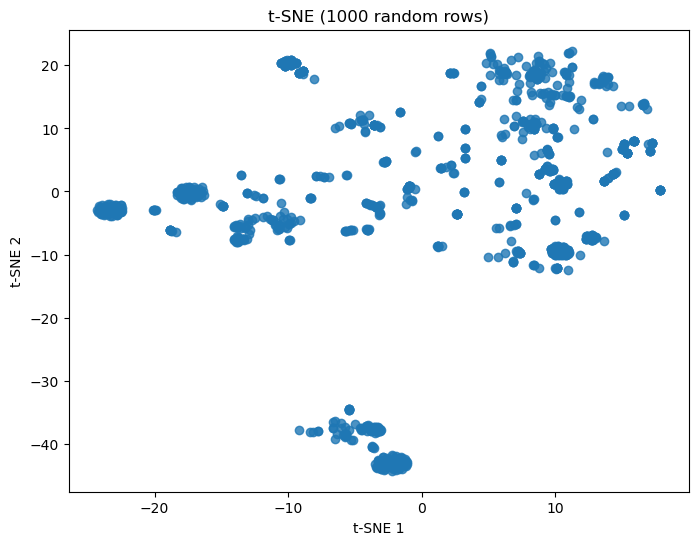

In [128]:
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.8)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE (1000 random rows)")
plt.show()


## Обучение моделей

### Кластеризация

In [6]:
from sklearn.cluster import HDBSCAN

clusterer = HDBSCAN(
    min_cluster_size=50,
    min_samples=10,
    metric="euclidean"
)

labels = clusterer.fit_predict(data)
data["cluster"] = labels

joblib.dump(clusterer, "../../../logs/clusterer.joblib")


['../../../logs/clustering.joblib']

In [15]:
clusterer

NameError: name 'clusterer' is not defined

In [9]:
data.to_csv("../logs/dataframe.csv", index=False)

In [2]:
data = pd.read_csv("../../logs/dataframe.csv")

In [10]:
data

,directory_feature_0,directory_feature_1,directory_feature_2,directory_feature_3,directory_feature_4,directory_feature_5,directory_feature_6,directory_feature_7,directory_feature_8,directory_feature_9,...,user_agent.os.name_iOS,user_agent.os.name_nan,user_agent.name_le,day,month,hour,minute,http.response.body.bytes_log2,ip_log2,cluster
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,4.0,9.0,12.0,0.0,0.0,12.962173,31.557408,-1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,6.0,9.0,12.0,0.0,23.0,8.960002,31.733032,-1
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.0,9.0,12.0,0.0,50.0,9.005625,29.719302,1
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.0,9.0,12.0,0.0,50.0,9.011227,29.719302,1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.0,9.0,12.0,0.0,50.0,9.016808,29.719302,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9401,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,9.0,12.0,16.0,40.0,11.298635,31.463277,-1
9402,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,9.0,12.0,16.0,40.0,13.782486,31.463277,-1
9403,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,9.0,12.0,16.0,40.0,10.699572,31.463277,-1
9404,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,9.0,12.0,16.0,40.0,11.718105,31.463277,-1


In [7]:
from sklearn.manifold import TSNE # здесь подключаем метод TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD

feature_cols = data.select_dtypes(include=['number']).columns
scaler = StandardScaler()
X_sample_scaled = scaler.fit_transform(data)
svd = TruncatedSVD(n_components=50, random_state=42)
X_reduced = svd.fit_transform(X_sample_scaled)

tsne = TSNE(
    n_components=2,
    perplexity=129,      # good for ~125 points
    init='pca',
    learning_rate='auto',
    random_state=42
)

X_tsne = tsne.fit_transform(X_reduced)



NameError: name 'copy_data' is not defined

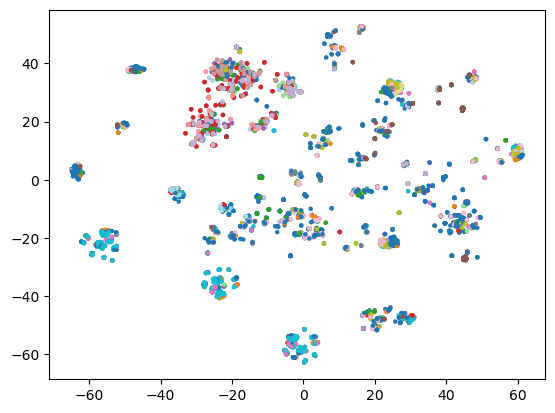

In [33]:
data['tsne_x'] = X_tsne[:, 0]
data['tsne_y'] = X_tsne[:, 1]

plt.scatter(data.tsne_x, data.tsne_y, c=data.cluster, cmap='tab20', s=5)
plt.show()


### Классификация

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = data.drop('cluster', axis=1)
y = data['cluster']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipe = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),  # IMPORTANT for sparse data
    ('clf', LogisticRegression(
        max_iter=3000,
        n_jobs=-1,
        solver='lbfgs'
    ))
])

pipe.fit(X_train, y_train)


,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,False
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [4]:
from sklearn.metrics import classification_report

y_pred = pipe.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

          -1       0.67      0.70      0.68       515
           0       0.94      0.77      0.85        22
           1       0.86      0.88      0.87        77
           2       0.68      0.53      0.60        32
           3       0.90      0.77      0.83        35
           4       0.76      0.73      0.75        26
           5       1.00      1.00      1.00        15
           6       0.89      0.86      0.88        29
           7       0.86      0.74      0.79        34
           8       0.73      0.65      0.69        17
           9       0.67      0.62      0.64        13
          10       0.96      0.81      0.88        31
          11       0.74      0.88      0.80        51
          12       0.93      0.68      0.79        19
          13       0.80      1.00      0.89        12
          14       0.93      0.82      0.88        17
          15       0.67      0.78      0.72        18
          16       0.71    

In [5]:
import joblib

joblib.dump(pipe, "log_classifier.joblib")


['log_classifier.joblib']

In [9]:
clusterer

NameError: name 'clusterer' is not defined

In [7]:
joblib.dump(clusterer, "../../data/clusterer.joblib")

NameError: name 'clusterer' is not defined

In [14]:
import pandas as pd
import scipy.sparse

# Create a 3x3 sparse matrix
sparse_matrix = scipy.sparse.eye(3)

# Convert to DataFrame
df = pd.DataFrame.sparse.from_spmatrix(sparse_matrix, columns=["red", "green", "blue"],)

df


,red,green,blue
0,1.0,0,0
1,0,1.0,0
2,0,0,1.0


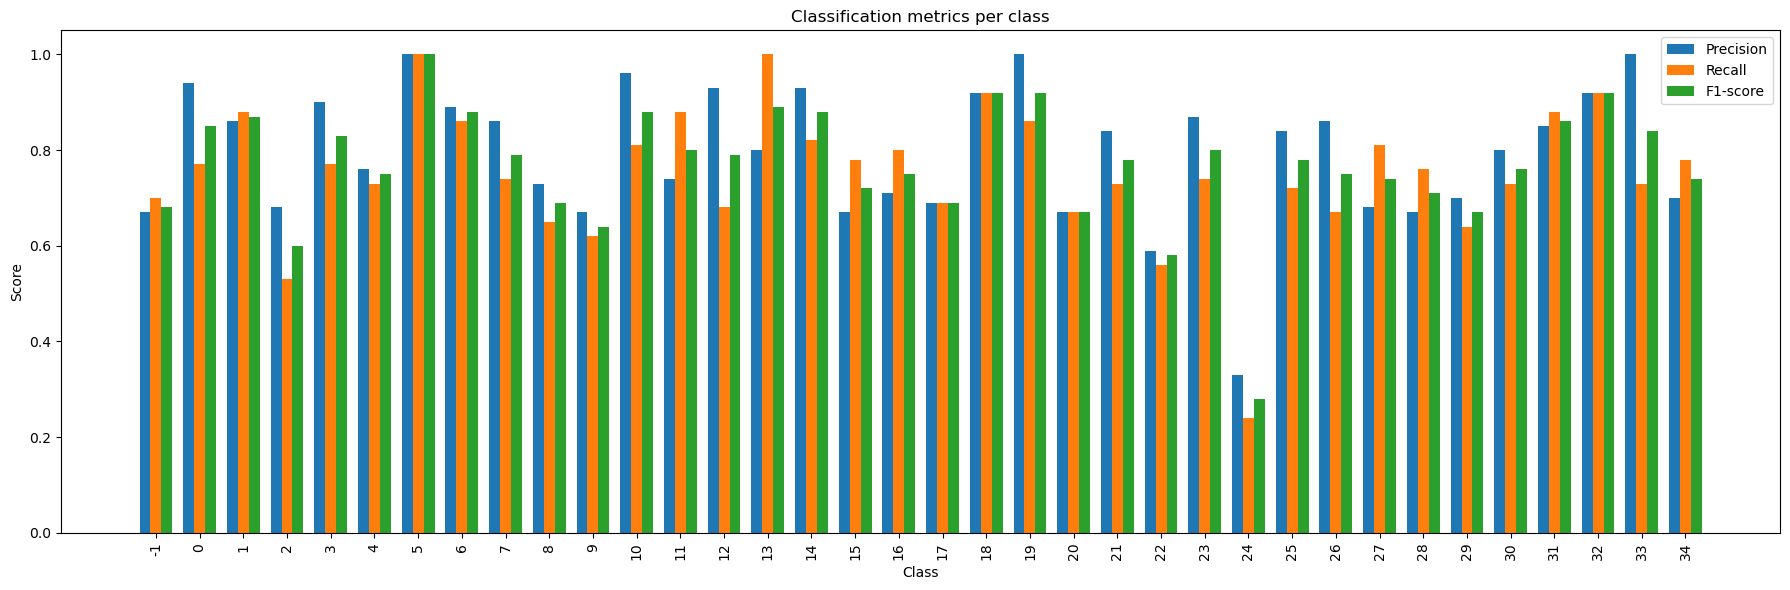

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Данные из classification report
classes = [
    -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
    11, 12, 13, 14, 15, 16, 17, 18, 19,
    20, 21, 22, 23, 24, 25, 26, 27, 28,
    29, 30, 31, 32, 33, 34
]

precision = [
    0.67, 0.94, 0.86, 0.68, 0.90, 0.76, 1.00, 0.89, 0.86,
    0.73, 0.67, 0.96, 0.74, 0.93, 0.80, 0.93, 0.67, 0.71,
    0.69, 0.92, 1.00, 0.67, 0.84, 0.59, 0.87, 0.33, 0.84,
    0.86, 0.68, 0.67, 0.70, 0.80, 0.85, 0.92, 1.00, 0.70
]

recall = [
    0.70, 0.77, 0.88, 0.53, 0.77, 0.73, 1.00, 0.86, 0.74,
    0.65, 0.62, 0.81, 0.88, 0.68, 1.00, 0.82, 0.78, 0.80,
    0.69, 0.92, 0.86, 0.67, 0.73, 0.56, 0.74, 0.24, 0.72,
    0.67, 0.81, 0.76, 0.64, 0.73, 0.88, 0.92, 0.73, 0.78
]

f1 = [
    0.68, 0.85, 0.87, 0.60, 0.83, 0.75, 1.00, 0.88, 0.79,
    0.69, 0.64, 0.88, 0.80, 0.79, 0.89, 0.88, 0.72, 0.75,
    0.69, 0.92, 0.92, 0.67, 0.78, 0.58, 0.80, 0.28, 0.78,
    0.75, 0.74, 0.71, 0.67, 0.76, 0.86, 0.92, 0.84, 0.74
]

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(18, 6))
plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1, width, label='F1-score')

plt.xticks(x, classes, rotation=90)
plt.ylim(0, 1.05)
plt.xlabel('Class')
plt.ylabel('Score')
plt.title('Classification metrics per class')
plt.legend()
plt.tight_layout()
plt.show()


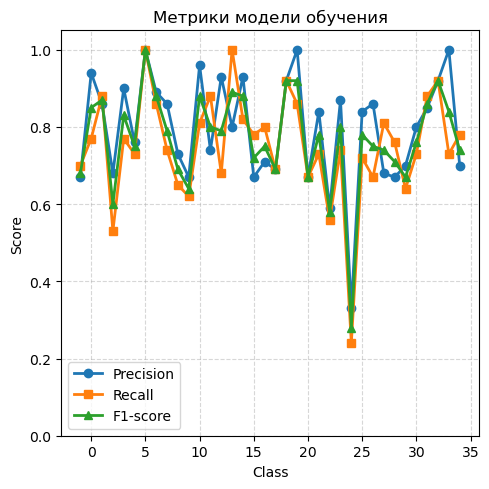

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Классы
classes = [
    -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
    11, 12, 13, 14, 15, 16, 17, 18, 19,
    20, 21, 22, 23, 24, 25, 26, 27, 28,
    29, 30, 31, 32, 33, 34
]

precision = [
    0.67, 0.94, 0.86, 0.68, 0.90, 0.76, 1.00, 0.89, 0.86,
    0.73, 0.67, 0.96, 0.74, 0.93, 0.80, 0.93, 0.67, 0.71,
    0.69, 0.92, 1.00, 0.67, 0.84, 0.59, 0.87, 0.33, 0.84,
    0.86, 0.68, 0.67, 0.70, 0.80, 0.85, 0.92, 1.00, 0.70
]

recall = [
    0.70, 0.77, 0.88, 0.53, 0.77, 0.73, 1.00, 0.86, 0.74,
    0.65, 0.62, 0.81, 0.88, 0.68, 1.00, 0.82, 0.78, 0.80,
    0.69, 0.92, 0.86, 0.67, 0.73, 0.56, 0.74, 0.24, 0.72,
    0.67, 0.81, 0.76, 0.64, 0.73, 0.88, 0.92, 0.73, 0.78
]

f1 = [
    0.68, 0.85, 0.87, 0.60, 0.83, 0.75, 1.00, 0.88, 0.79,
    0.69, 0.64, 0.88, 0.80, 0.79, 0.89, 0.88, 0.72, 0.75,
    0.69, 0.92, 0.92, 0.67, 0.78, 0.58, 0.80, 0.28, 0.78,
    0.75, 0.74, 0.71, 0.67, 0.76, 0.86, 0.92, 0.84, 0.74
]

plt.figure(figsize=(5, 5))

plt.plot(classes, precision, marker='o', linewidth=2, label='Precision')
plt.plot(classes, recall, marker='s', linewidth=2, label='Recall')
plt.plot(classes, f1, marker='^', linewidth=2, label='F1-score')

plt.xlabel('Class')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.title('Метрики модели обучения')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


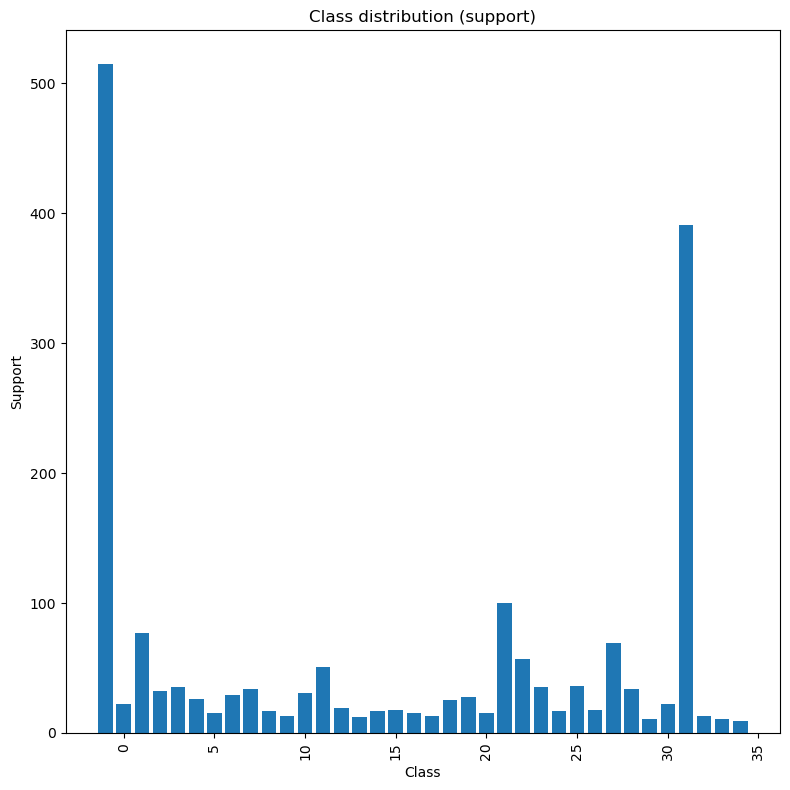

In [2]:
support = [
    515, 22, 77, 32, 35, 26, 15, 29, 34, 17, 13,
    31, 51, 19, 12, 17, 18, 15, 13, 25, 28,
    15, 100, 57, 35, 17, 36, 18, 69, 34,
    11, 22, 391, 13, 11, 9
]

plt.figure(figsize=(8, 8))
plt.bar(classes, support)
plt.xlabel('Class')
plt.ylabel('Support')
plt.title('Class distribution (support)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


Saved plot to artifacts/ml_latency.png
Average: 1210.00 ms, P95: 1240.85 ms, errors: 0
[]


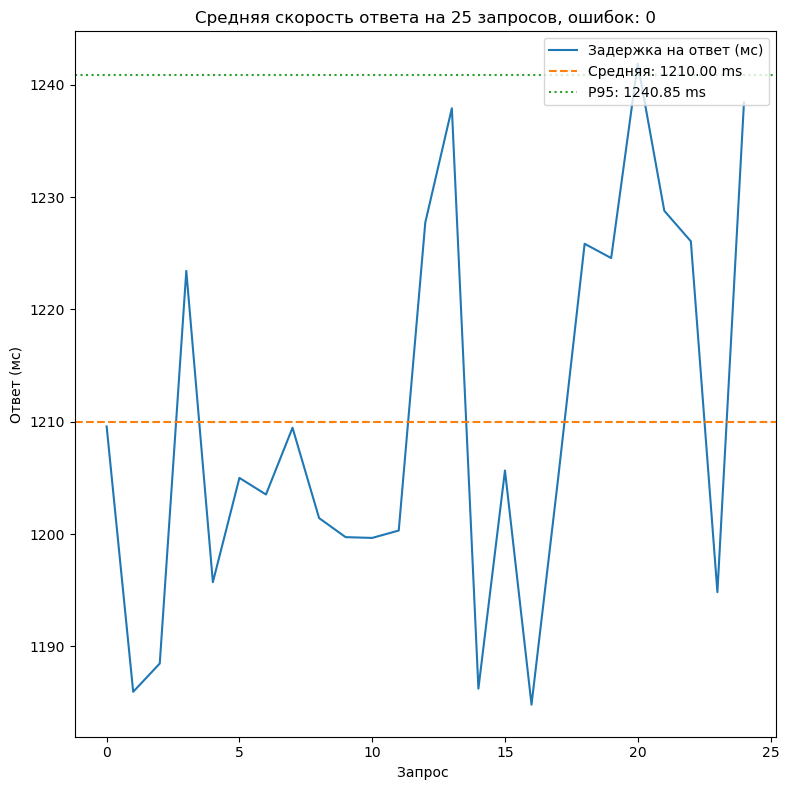

In [10]:
#!/usr/bin/env python3
import argparse
import json
import statistics
import time
from pathlib import Path

import matplotlib.pyplot as plt
import requests


DEFAULT_PAYLOAD = {
    "source": {"ip": "31.185.5.73"},
    "type": "apache_access",
    "@timestamp": "2025-12-08T22:32:13.000Z",
    "event": {
        "original": (
            "31.185.5.73 - - [09/Dec/2025:01:32:13 +0300] "
            "\"GET /lib/javascript.php/1758485667/lib/requirejs/require.min.js HTTP/1.1\" "
            "200 9685 \"https://it548.ru/login/index.php\" "
            "\"Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) Chrome/140.0.0.0 "
            "YaBrowser/25.10.0.0 Safari/537.36\""
        ),
        "type": ["access", "connection"],
        "dataset": "apache.access",
        "module": "apache",
        "category": ["web", "authentication"],
        "kind": "event",
    },
    "host": {"name": "e9828ba7e444"},
    "message": (
        "31.185.5.73 - - [09/Dec/2025:01:32:13 +0300] "
        "\"GET /lib/javascript.php/1758485667/lib/requirejs/require.min.js HTTP/1.1\" "
        "200 9685 \"https://it548.ru/login/index.php\" "
        "\"Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) Chrome/140.0.0.0 "
        "YaBrowser/25.10.0.0 Safari/537.36\""
    ),
    "http": {
        "response": {"status_code": 200, "body": {"bytes": 9685}},
        "version": "1.1",
        "request": {"referrer": "https://it548.ru/login/index.php", "method": "GET"},
    },
    "url": {
        "original": "/lib/javascript.php/1758485667/lib/requirejs/require.min.js",
        "path": "/lib/javascript.php/1758485667/lib/requirejs/require.min.js",
    },
    "user_agent": {
        "original": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) Chrome/140.0.0.0 "
            "YaBrowser/25.10.0.0 Safari/537.36"
        ),
        "version": "25.10.0.0",
        "os": {"version": "10", "full": "Windows 10", "name": "Windows"},
        "device": {"name": "Other"},
        "name": "Yandex Browser",
    },
    "ecs": {"version": "8.0"},
    "log": {"file": {"path": "/var/log/test_logs/moodle_access.log"}},
}


def load_payload(path: str | None) -> dict:
    if not path:
        return DEFAULT_PAYLOAD
    with open(path, "r", encoding="utf-8") as fh:
        return json.load(fh)


def main() -> None:
    # parser = argparse.ArgumentParser(description="Plot ML service latency for /classify")
    # parser.add_argument("--url", default="http://localhost:8000", help="Base ML service URL")
    # parser.add_argument("--endpoint", default="/classify", help="Classification endpoint path")
    # parser.add_argument("--requests", type=int, default=25, help="Number of requests to send")
    # parser.add_argument("--warmup", type=int, default=5, help="Number of warmup requests")
    # parser.add_argument("--timeout", type=float, default=10.0, help="Request timeout, seconds")
    # parser.add_argument("--payload", default=None, help="Path to JSON payload file")
    # parser.add_argument("--out", default="artifacts/ml_latency.png", help="Output plot path")
    # args = parser.parse_args()

    # payload = load_payload(DEFAULT_PAYLOAD)
    endpoint = "http://localhost:8000".rstrip("/") + "/classify"
    Path("artifacts/ml_latency.png").parent.mkdir(parents=True, exist_ok=True)

    for _ in range(5):
        try:
            requests.post(endpoint, json=DEFAULT_PAYLOAD, timeout=10.0)
        except Exception:
            pass

    timings_ms = []
    errors, errl = 0, []
    for _ in range(25):
        t0 = time.perf_counter()
        try:
            resp = requests.post(endpoint, json=DEFAULT_PAYLOAD, timeout=10.0)
            if resp.status_code >= 400:
                errors += 1
                errl.append(resp)
        except Exception:
            errors += 1
        t1 = time.perf_counter()
        timings_ms.append((t1 - t0) * 1000.0)

    avg_ms = statistics.mean(timings_ms) if timings_ms else 0.0
    p95_ms = statistics.quantiles(timings_ms, n=20)[18] if len(timings_ms) >= 20 else max(timings_ms, default=0.0)

    plt.figure(figsize=(8, 8))
    plt.plot(timings_ms, label="Задержка на ответ (мс)", color="#1f77b4")
    plt.axhline(avg_ms, color="#ff7f0e", linestyle="--", label=f"Средняя: {avg_ms:.2f} ms")
    plt.axhline(p95_ms, color="#2ca02c", linestyle=":", label=f"P95: {p95_ms:.2f} ms")
    plt.title(f"Средняя скорость ответа на {25} запросов, ошибок: {errors}")
    plt.xlabel("Запрос ")
    plt.ylabel("Ответ (мс)")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.savefig("artifacts/ml_latency.png", dpi=150)
    print(f"Saved plot to artifacts/ml_latency.png")
    print(f"Average: {avg_ms:.2f} ms, P95: {p95_ms:.2f} ms, errors: {errors}")
    print(errl)


main()
